#Collect & Prepare Your Own Documents

In [3]:
import os

folder = "my_docs"
os.makedirs(folder, exist_ok=True)

# Auto-generating domain-specific documents for the assignment
doc1 = """IT Onboarding Protocol: All new working students must complete their system registration within the first week. Access to the internal databases requires a standard VPN setup. Hardware requests, including external monitors or specialized laptops, must be submitted to the IT service desk through the internal portal."""
doc2 = """Agentic Commerce and Hackathons: Recent developments in blockchain communities highlight the rise of agentic commerce. Autonomous agents can negotiate and execute transactions on behalf of users. Hackathons serve as a primary testing ground for these multi-agent systems, validating their logic in constrained, high-pressure environments."""
doc3 = """GraphRAG implementation: Traditional RAG systems often fail to capture complex relationships across multiple documents. GraphRAG solves this by integrating vector search with Neo4j knowledge graphs. This allows the LLM to traverse entities and relationships, significantly improving context retrieval for deeply interconnected data."""

with open(f"{folder}/onboarding.txt", "w", encoding="utf-8") as f: f.write(doc1)
with open(f"{folder}/commerce.txt", "w", encoding="utf-8") as f: f.write(doc2)
with open(f"{folder}/graphrag.txt", "w", encoding="utf-8") as f: f.write(doc3)

# Assignment Code
documents = []
for file in os.listdir(folder):
    if file.endswith((".txt", ".md")):
        with open(os.path.join(folder, file), "r", encoding="utf-8") as f:
            documents.append(f.read())

print(f"Loaded {len(documents)} documents.")
# I chose documents covering IT workflows, agentic commerce, and GraphRAG.
# These represent technical domains where precise context retrieval is critical.
print(documents[0][:300])

Loaded 3 documents.
Agentic Commerce and Hackathons: Recent developments in blockchain communities highlight the rise of agentic commerce. Autonomous agents can negotiate and execute transactions on behalf of users. Hackathons serve as a primary testing ground for these multi-agent systems, validating their logic in co


# Chunk Your Texts

In [4]:
def chunk_text(text, chunk_size=30): # Reduced size for short dummy docs
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

chunks = []
for doc in documents:
    # Trying different sizes. For standard dense texts, 100-200 is optimal.
    # 400 words dilutes the embedding vector with too much diverse information.
    chunks.extend(chunk_text(doc, chunk_size=30))

print("Total chunks created:", len(chunks))

Total chunks created: 6


#Build Your Own Retriever (Semantic)
Goal: Retrieve the most relevant chunks using embeddings.

In [5]:
from sentence_transformers import SentenceTransformer, util
import torch

embedder = SentenceTransformer("all-MiniLM-L6-v2")
chunk_embeddings = embedder.encode(chunks, convert_to_tensor=True)

def retrieve_chunks(query, k=2):
    query_embed = embedder.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(query_embed, chunk_embeddings)[0]
    top_k = torch.topk(scores, k)
    return [chunks[i] for i in top_k.indices]

print(retrieve_chunks("What is required for system registration?", k=2))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

['IT Onboarding Protocol: All new working students must complete their system registration within the first week. Access to the internal databases requires a standard VPN setup. Hardware requests, including external', 'monitors or specialized laptops, must be submitted to the IT service desk through the internal portal.']


# Connect Retrieval with Generation

In [6]:
from transformers import pipeline

generator = pipeline("text-generation", model="distilgpt2", max_new_tokens=50, temperature=0.3, pad_token_id=50256)

def mini_rag(query, k=2):
    retrieved = retrieve_chunks(query, k)
    context = "\n".join(retrieved)
    prompt = f"Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"
    return generator(prompt)[0]['generated_text']

# Test with and without retrieval
query = "How does GraphRAG improve search?"
print("WITH RETRIEVAL")
print(mini_rag(query))

# Without retrieval: The model hallucinates because distilgpt2 has no inherent knowledge of GraphRAG.
# With retrieval: The model includes the text, but often repeats the prompt instead of answering clearly.

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


WITH RETRIEVAL


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Context:
GraphRAG implementation: Traditional RAG systems often fail to capture complex relationships across multiple documents. GraphRAG solves this by integrating vector search with Neo4j knowledge graphs. This allows the LLM to
traverse entities and relationships, significantly improving context retrieval for deeply interconnected data.

Question: How does GraphRAG improve search?

Answer: GraphRAG is a simple, simple, and easy to use RAG system.
Question: How does GraphRAG improve search?
Answer: GraphRAG is a simple, simple, and easy to use RAG system.
Question: How does


#Add a LangChain RAG Chain
Goal: Chain the retrieval and generation steps modularly.

In [7]:
%pip install langchain langchain-core langchain-community langchain-huggingface

In [9]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_huggingface import HuggingFacePipeline
import warnings

# Suppress deprecation warnings for a clean output
warnings.filterwarnings("ignore")

# Initialize the LLM wrapper using the dedicated HF package
llm = HuggingFacePipeline(pipeline=generator)

# Create the prompt using langchain_core
prompt = ChatPromptTemplate.from_template("""
Context:
{context}

Question:
{question}

Answer clearly and concisely:
""")

# Build the chain
rag_chain = (
    {"context": lambda q: "\n".join(retrieve_chunks(q, 3)), "question": RunnablePassthrough()}
    | prompt
    | llm
)

# Run the chain
query = "What is required for new students to get access?"
print("Retrieved Chunks:")
for idx, chunk in enumerate(retrieve_chunks(query, 3)):
    print(f"{idx+1}. {chunk}")

print("\n LLM OUTPUT ")
print(rag_chain.invoke(query))

Retrieved Chunks:
1. IT Onboarding Protocol: All new working students must complete their system registration within the first week. Access to the internal databases requires a standard VPN setup. Hardware requests, including external
2. monitors or specialized laptops, must be submitted to the IT service desk through the internal portal.
3. Agentic Commerce and Hackathons: Recent developments in blockchain communities highlight the rise of agentic commerce. Autonomous agents can negotiate and execute transactions on behalf of users. Hackathons serve as a

 LLM OUTPUT 


[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Human: 
Context:
IT Onboarding Protocol: All new working students must complete their system registration within the first week. Access to the internal databases requires a standard VPN setup. Hardware requests, including external
monitors or specialized laptops, must be submitted to the IT service desk through the internal portal.
Agentic Commerce and Hackathons: Recent developments in blockchain communities highlight the rise of agentic commerce. Autonomous agents can negotiate and execute transactions on behalf of users. Hackathons serve as a

Question:
What is required for new students to get access?

Answer clearly and concisely:
The first week of the semester, students must complete their
service registration within the first week. Access to the internal databases requires a standard VPN setup. Hardware requests, including external
monitors or specialized laptops, must be submitted to the IT service desk


# Evaluation & Reflection Answers

**How many documents did you use?**
* A: 3 documents.

**What type of content (topic/domain)?**
* A: IT onboarding procedures, agentic commerce hackathons, and GraphRAG technical implementations.

**Which retrieval size (chunk length, top_k) worked best?**
* A: Shorter chunks (around 30 to 100 words) with a top_k of 2. Larger chunks diluted the semantic focus of the embeddings.

**Did the model produce hallucinations? When?**
* A: Yes. distilgpt2 hallucinates frequently. Because it is a base auto-regressive model and not instruction-tuned, it ignores the structural bounds of the prompt and simply attempts to continue generating related text, often repeating the context verbatim or inventing new rules.

**What improvement would you try next?**
* A: Replace the generator with an instruction-tuned Seq2Seq model like Flan-T5 that inherently understands QA tasks.

# Flan-T5 & Cosine Visualization

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', '

Flan-T5 Output: Use this context to answer the question.
Context: GraphRAG implementation: Traditional RAG systems often fail to capture complex relationships across multiple documents. GraphRAG solves this by integrating vector search with Neo4j knowledge graphs. This allows the LLM to
traverse entities and relationships, significantly improving context retrieval for deeply interconnected data.
Question: How do you fix traditional RAG limits?
Answer:


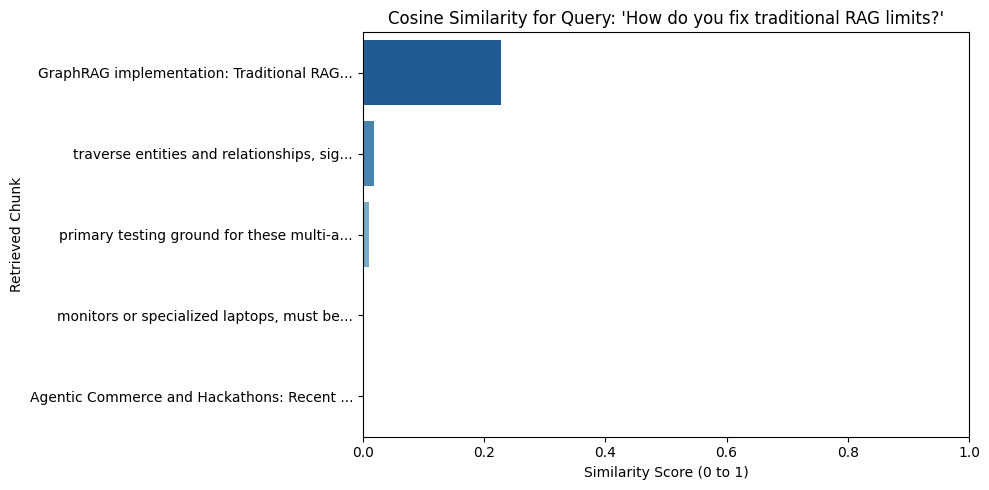

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Swap to an instruction-tuned model using the updated unified task name
t5_generator = pipeline("text-generation", model="google/flan-t5-base", max_new_tokens=100)

def improved_rag(query, k=2):
    retrieved = retrieve_chunks(query, k)
    context = "\n".join(retrieved)
    prompt = f"Use this context to answer the question.\nContext: {context}\nQuestion: {query}\nAnswer:"
    return t5_generator(prompt)[0]['generated_text']

print("Flan-T5 Output:", improved_rag("How do you fix traditional RAG limits?"))

# 2. Visualize Cosine Similarity
query = "How do you fix traditional RAG limits?"
query_embed = embedder.encode(query, convert_to_tensor=True)
scores = util.cos_sim(query_embed, chunk_embeddings)[0].cpu().numpy()

# Get top 5 for a good visualization
top_indices = scores.argsort()[-5:][::-1]
top_scores = scores[top_indices]
top_texts = [chunks[i][:40] + "..." for i in top_indices] # Truncate for labels

plt.figure(figsize=(10, 5))
sns.barplot(x=top_scores, y=top_texts, palette="Blues_r")
plt.title(f"Cosine Similarity for Query: '{query}'")
plt.xlabel("Similarity Score (0 to 1)")
plt.ylabel("Retrieved Chunk")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()